# BigGAN + MidJourney: Common 4 Classes, IQA + FFT + CLIP + XGBoost / MLP

Notebook ini menggabungkan tiga keluarga fitur sekaligus: **NR-IQA**, **FFT mean**, dan **CLIP image embedding**. Setup data tetap sama seperti notebook `08`?`11`.

In [1]:
from pathlib import Path
import hashlib
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyiqa
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from transformers import CLIPModel, CLIPProcessor
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..")
DATA_ROOTS = {
    "BigGAN": PROJECT_ROOT / "data" / "raw" / "genimage" / "BigGAN" / "train",
    "MidJourney": PROJECT_ROOT / "data" / "raw" / "genimage" / "MidJourney" / "train",
}
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
COMMON_CLASSES = {
    "114": "n01945685",
    "281": "n02123045",
    "654": "n03769881",
    "759": "n04069434",
}
COMMON_WNIDS = set(COMMON_CLASSES.values())
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
CLIP_OUT_DIM = 64

print("Data roots:")
for k, v in DATA_ROOTS.items():
    print(k, v.resolve())
print("Common classes:", COMMON_CLASSES)
SUBSET_NAME = "biggan_midjourney_common4_train"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_biggan_midjourney_common4_train.csv"
FFT_OUT = PROJECT_ROOT / "artifacts" / "features_fft_mean_biggan_midjourney_common4_train.csv"
CLIP_OUT = PROJECT_ROOT / "artifacts" / "features_clip_biggan_midjourney_common4_train.csv"
IQA_OUT = PROJECT_ROOT / "artifacts" / "features_iqa_biggan_midjourney_common4_train.csv"
VECTOR_OUT = PROJECT_ROOT / "artifacts" / "feature_vector_biggan_midjourney_common4_iqa_fft_clip.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_biggan_midjourney_common4_iqa_fft_clip.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_biggan_midjourney_common4_iqa_fft_clip.csv"

/home/nanda/miniconda3/envs/ai/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data roots:
BigGAN /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/BigGAN/train
MidJourney /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/MidJourney/train
Common classes: {'114': 'n01945685', '281': 'n02123045', '654': 'n03769881', '759': 'n04069434'}


## 1. Audit data per generator

In [2]:
mapping = json.loads(IMAGENET_MAP.read_text())
idx_to_info = {int(k): tuple(v) for k, v in mapping.items()}
wnid_to_label = {v[0]: v[1] for v in mapping.values()}

def is_valid_image_file(path: Path) -> bool:
    if not path.is_file():
        return False
    if ":Zone.Identifier" in path.name:
        return False
    return path.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

audit_rows = []
for gen_name, data_root in DATA_ROOTS.items():
    ai_files = [p for p in (data_root / "ai").iterdir() if is_valid_image_file(p)]
    nature_files = [p for p in (data_root / "nature").iterdir() if is_valid_image_file(p)]

    ai_counts = Counter()
    nature_counts = Counter()

    for p in ai_files:
        m = re.match(r"(\d{3})_", p.name)
        if m and m.group(1) in COMMON_CLASSES:
            ai_counts[m.group(1)] += 1
    for p in nature_files:
        m = re.match(r"(n\d{8})_", p.name)
        if m and m.group(1) in COMMON_WNIDS:
            nature_counts[m.group(1)] += 1

    for class_idx, count in sorted(ai_counts.items()):
        audit_rows.append({
            "generator": gen_name,
            "side": "ai",
            "content_id": class_idx,
            "label": idx_to_info[int(class_idx)][1],
            "count": count,
        })
    for wnid, count in sorted(nature_counts.items()):
        audit_rows.append({
            "generator": gen_name,
            "side": "nature",
            "content_id": wnid,
            "label": wnid_to_label[wnid],
            "count": count,
        })

audit_df = pd.DataFrame(audit_rows)
display(audit_df.sort_values(["generator", "side", "content_id"]))

,generator,side,content_id,label,count
0,BigGAN,ai,114,slug,100
1,BigGAN,ai,281,tabby,100
2,BigGAN,ai,654,minibus,100
3,BigGAN,ai,759,reflex_camera,100
4,BigGAN,nature,n01945685,slug,100
5,BigGAN,nature,n02123045,tabby,100
6,BigGAN,nature,n03769881,minibus,100
7,BigGAN,nature,n04069434,reflex_camera,100
8,MidJourney,ai,114,slug,100
9,MidJourney,ai,281,tabby,100


## 2. Bangun manifest gabungan untuk 4 class yang sama

In [3]:
rows = []
for gen_name, data_root in DATA_ROOTS.items():
    ai_dir = data_root / "ai"
    nature_dir = data_root / "nature"

    ai_files = sorted([p for p in ai_dir.iterdir() if is_valid_image_file(p)])
    nature_files = sorted([p for p in nature_dir.iterdir() if is_valid_image_file(p)])

    for p in ai_files:
        m = re.match(r"(\d{3})_", p.name)
        if not m or m.group(1) not in COMMON_CLASSES:
            continue
        class_idx = m.group(1)
        image_id = "img_" + hashlib.sha1(f"{gen_name}:{p}".encode("utf-8")).hexdigest()[:16]
        rows.append({
            "image_id": image_id,
            "path": str(p.resolve()),
            "relative_path": str(p.relative_to(data_root)),
            "generator": gen_name,
            "subset_name": SUBSET_NAME,
            "split": "train",
            "class_name": "ai",
            "content_id": class_idx,
            "content_label": idx_to_info[int(class_idx)][1],
            "is_real": 0,
            "y_ai": 1,
        })

    for p in nature_files:
        m = re.match(r"(n\d{8})_", p.name)
        if not m or m.group(1) not in COMMON_WNIDS:
            continue
        wnid = m.group(1)
        image_id = "img_" + hashlib.sha1(f"{gen_name}:{p}".encode("utf-8")).hexdigest()[:16]
        rows.append({
            "image_id": image_id,
            "path": str(p.resolve()),
            "relative_path": str(p.relative_to(data_root)),
            "generator": gen_name,
            "subset_name": SUBSET_NAME,
            "split": "train",
            "class_name": "nature",
            "content_id": wnid,
            "content_label": wnid_to_label[wnid],
            "is_real": 1,
            "y_ai": 0,
        })

manifest = pd.DataFrame(rows)
manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())
display(manifest.groupby(["generator", "y_ai"]).size().rename("count").reset_index())

Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_biggan_midjourney_common4_train.csv
Manifest shape: (1600, 11)


,image_id,path,relative_path,generator,subset_name,split,class_name,content_id,content_label,is_real,y_ai
0,img_99750ec53b35c7c0,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00000.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,1
1,img_c0aacdc302b75723,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00001.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,1
2,img_352b0b2f2415e399,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00002.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,1
3,img_c295e48b71877b6e,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00004.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,1
4,img_2a8cddc25ea810de,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00005.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,1


,generator,y_ai,count
0,BigGAN,0,400
1,BigGAN,1,400
2,MidJourney,0,400
3,MidJourney,1,400


## 3. Ekstraksi fitur

In [4]:
def load_gray(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)

def extract_fft_mean(gray):
    f = np.fft.fft2(gray)
    mag = np.abs(f)
    phase = np.angle(f)
    return {
        "fft_mag_mean": float(np.mean(mag)),
        "fft_phase_mean": float(np.mean(phase)),
        "fft_phase_cos_mean": float(np.mean(np.cos(phase))),
        "fft_phase_sin_mean": float(np.mean(np.sin(phase))),
    }

fft_rows = []
for row in manifest.itertuples(index=False):
    gray = load_gray(row.path)
    feats = extract_fft_mean(gray)
    fft_rows.append({"image_id": row.image_id, **feats})

fft_df = pd.DataFrame(fft_rows)
fft_df.to_csv(FFT_OUT, index=False)
print("Saved FFT features:", FFT_OUT.resolve())
display(fft_df.head())

device = "cuda" if torch.cuda.is_available() else "cpu"
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
model = CLIPModel.from_pretrained(CLIP_MODEL_NAME, local_files_only=True).to(device)
model.eval()
print("device:", device)
print("projection_dim:", model.config.projection_dim)

def extract_clip_vector(path: str, out_dim: int = 64):
    image = Image.open(path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        out = model.get_image_features(**inputs)
        if hasattr(out, "pooler_output"):
            feats = out.pooler_output
        elif torch.is_tensor(out):
            feats = out
        else:
            raise TypeError(f"Unexpected CLIP output type: {type(out)}")
        feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
    vec = feats.squeeze(0).detach().cpu().numpy().astype(np.float32)
    if out_dim < vec.shape[0]:
        vec = vec[:out_dim]
    elif out_dim > vec.shape[0]:
        vec = np.concatenate([vec, np.zeros(out_dim - vec.shape[0], dtype=np.float32)])
    return vec

clip_rows = []
for row in manifest.itertuples(index=False):
    vec = extract_clip_vector(row.path, out_dim=CLIP_OUT_DIM)
    item = {"image_id": row.image_id}
    for i, v in enumerate(vec):
        item[f"clip_feat_{i:03d}"] = float(v)
    clip_rows.append(item)

clip_df = pd.DataFrame(clip_rows)
clip_df.to_csv(CLIP_OUT, index=False)
print("Saved CLIP features:", CLIP_OUT.resolve())
display(clip_df.head())

device = "cuda" if torch.cuda.is_available() else "cpu"
metric_piqe = pyiqa.create_metric("piqe", device=device)
metric_brisque = pyiqa.create_metric("brisque", device=device)
metric_niqe = pyiqa.create_metric("niqe", device=device)
print("device:", device)

def extract_iqa_scores(path: str):
    with torch.no_grad():
        piqe = float(metric_piqe(path).item())
        brisque = float(metric_brisque(path).item())
        niqe = float(metric_niqe(path).item())
    return {
        "piqe": piqe,
        "brisque": brisque,
        "niqe": niqe,
    }

iqa_rows = []
for row in manifest.itertuples(index=False):
    scores = extract_iqa_scores(row.path)
    iqa_rows.append({"image_id": row.image_id, **scores})

iqa_df = pd.DataFrame(iqa_rows)
iqa_df.to_csv(IQA_OUT, index=False)
print("Saved IQA features:", IQA_OUT.resolve())
display(iqa_df.head())

Saved FFT features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_fft_mean_biggan_midjourney_common4_train.csv


,image_id,fft_mag_mean,fft_phase_mean,fft_phase_cos_mean,fft_phase_sin_mean
0,img_99750ec53b35c7c0,1632.850586,1.917481e-04,0.050193,0.000000e+00
1,img_c0aacdc302b75723,1915.559204,-1.862645e-09,-0.000166,-4.656613e-10
2,img_352b0b2f2415e399,1228.959473,3.834907e-04,-0.003206,-2.328306e-10
3,img_c295e48b71877b6e,3144.210938,1.917481e-04,-0.004117,1.862645e-09
4,img_2a8cddc25ea810de,2442.263672,-1.862645e-09,0.008334,9.313226e-10


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 8312.17it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cpu
projection_dim: 512
Saved CLIP features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_clip_biggan_midjourney_common4_train.csv


,image_id,clip_feat_000,clip_feat_001,clip_feat_002,clip_feat_003,clip_feat_004,clip_feat_005,clip_feat_006,clip_feat_007,clip_feat_008,...,clip_feat_054,clip_feat_055,clip_feat_056,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063
0,img_99750ec53b35c7c0,-0.004890,0.022956,0.018309,0.015773,-0.015953,-0.011832,0.000899,0.000423,0.025995,...,-0.004555,-0.011196,-0.047428,0.054747,-0.000386,0.018999,0.116672,0.029469,-0.028217,-0.016718
1,img_c0aacdc302b75723,0.031145,0.006834,-0.026824,-0.014264,0.000285,-0.005798,-0.004836,0.028968,0.061423,...,0.013181,0.001139,0.017804,0.067389,0.021181,-0.014638,0.053659,-0.032303,-0.068252,-0.032249
2,img_352b0b2f2415e399,0.013343,0.028012,-0.020339,0.016758,-0.009596,0.016541,0.031393,0.012720,-0.010638,...,0.008772,0.015938,0.026855,0.053301,-0.013094,0.012531,0.077262,0.002565,-0.038987,-0.019717
3,img_c295e48b71877b6e,0.011084,0.014182,-0.023442,0.021509,-0.009134,-0.013882,0.027260,0.009335,0.066003,...,0.014291,-0.036446,-0.010016,0.035166,-0.014316,-0.042307,0.102771,-0.024485,-0.057920,-0.003295
4,img_2a8cddc25ea810de,0.026384,0.025029,-0.007688,0.002601,0.017721,0.010307,-0.005523,0.039922,0.064762,...,0.028705,0.005076,0.008727,0.078178,0.019824,-0.024218,0.030663,-0.032998,-0.058188,-0.013460


device: cpu
Saved IQA features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_iqa_biggan_midjourney_common4_train.csv


,image_id,piqe,brisque,niqe
0,img_99750ec53b35c7c0,26.959890,25.515503,5.555550
1,img_c0aacdc302b75723,48.425323,23.925964,7.823172
2,img_352b0b2f2415e399,29.457823,27.673828,11.646940
3,img_c295e48b71877b6e,36.009182,17.784607,6.873159
4,img_2a8cddc25ea810de,44.664524,20.501770,4.657476


## 4. Bangun feature vector

In [5]:
data = manifest.merge(fft_df, on="image_id", how="inner").merge(clip_df, on="image_id", how="inner").merge(iqa_df, on="image_id", how="inner")
meta_cols = ["image_id", "path", "relative_path", "generator", "subset_name", "split", "class_name", "content_id", "content_label", "is_real", "y_ai"]
feature_cols = [c for c in data.columns if c not in meta_cols]

data.to_csv(VECTOR_OUT, index=False)
print("Merged shape:", data.shape)
print("Feature dims:", len(feature_cols))
print("Saved vector:", VECTOR_OUT.resolve())
display(data.head())

Merged shape: (1600, 82)
Feature dims: 71
Saved vector: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/feature_vector_biggan_midjourney_common4_iqa_fft_clip.csv


,image_id,path,relative_path,generator,subset_name,split,class_name,content_id,content_label,is_real,...,clip_feat_057,clip_feat_058,clip_feat_059,clip_feat_060,clip_feat_061,clip_feat_062,clip_feat_063,piqe,brisque,niqe
0,img_99750ec53b35c7c0,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00000.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,...,0.054747,-0.000386,0.018999,0.116672,0.029469,-0.028217,-0.016718,26.959890,25.515503,5.555550
1,img_c0aacdc302b75723,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00001.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,...,0.067389,0.021181,-0.014638,0.053659,-0.032303,-0.068252,-0.032249,48.425323,23.925964,7.823172
2,img_352b0b2f2415e399,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00002.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,...,0.053301,-0.013094,0.012531,0.077262,0.002565,-0.038987,-0.019717,29.457823,27.673828,11.646940
3,img_c295e48b71877b6e,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00004.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,...,0.035166,-0.014316,-0.042307,0.102771,-0.024485,-0.057920,-0.003295,36.009182,17.784607,6.873159
4,img_2a8cddc25ea810de,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_biggan_00005.png,BigGAN,biggan_midjourney_common4_train,train,ai,114,slug,0,...,0.078178,0.019824,-0.024218,0.030663,-0.032998,-0.058188,-0.013460,44.664524,20.501770,4.657476


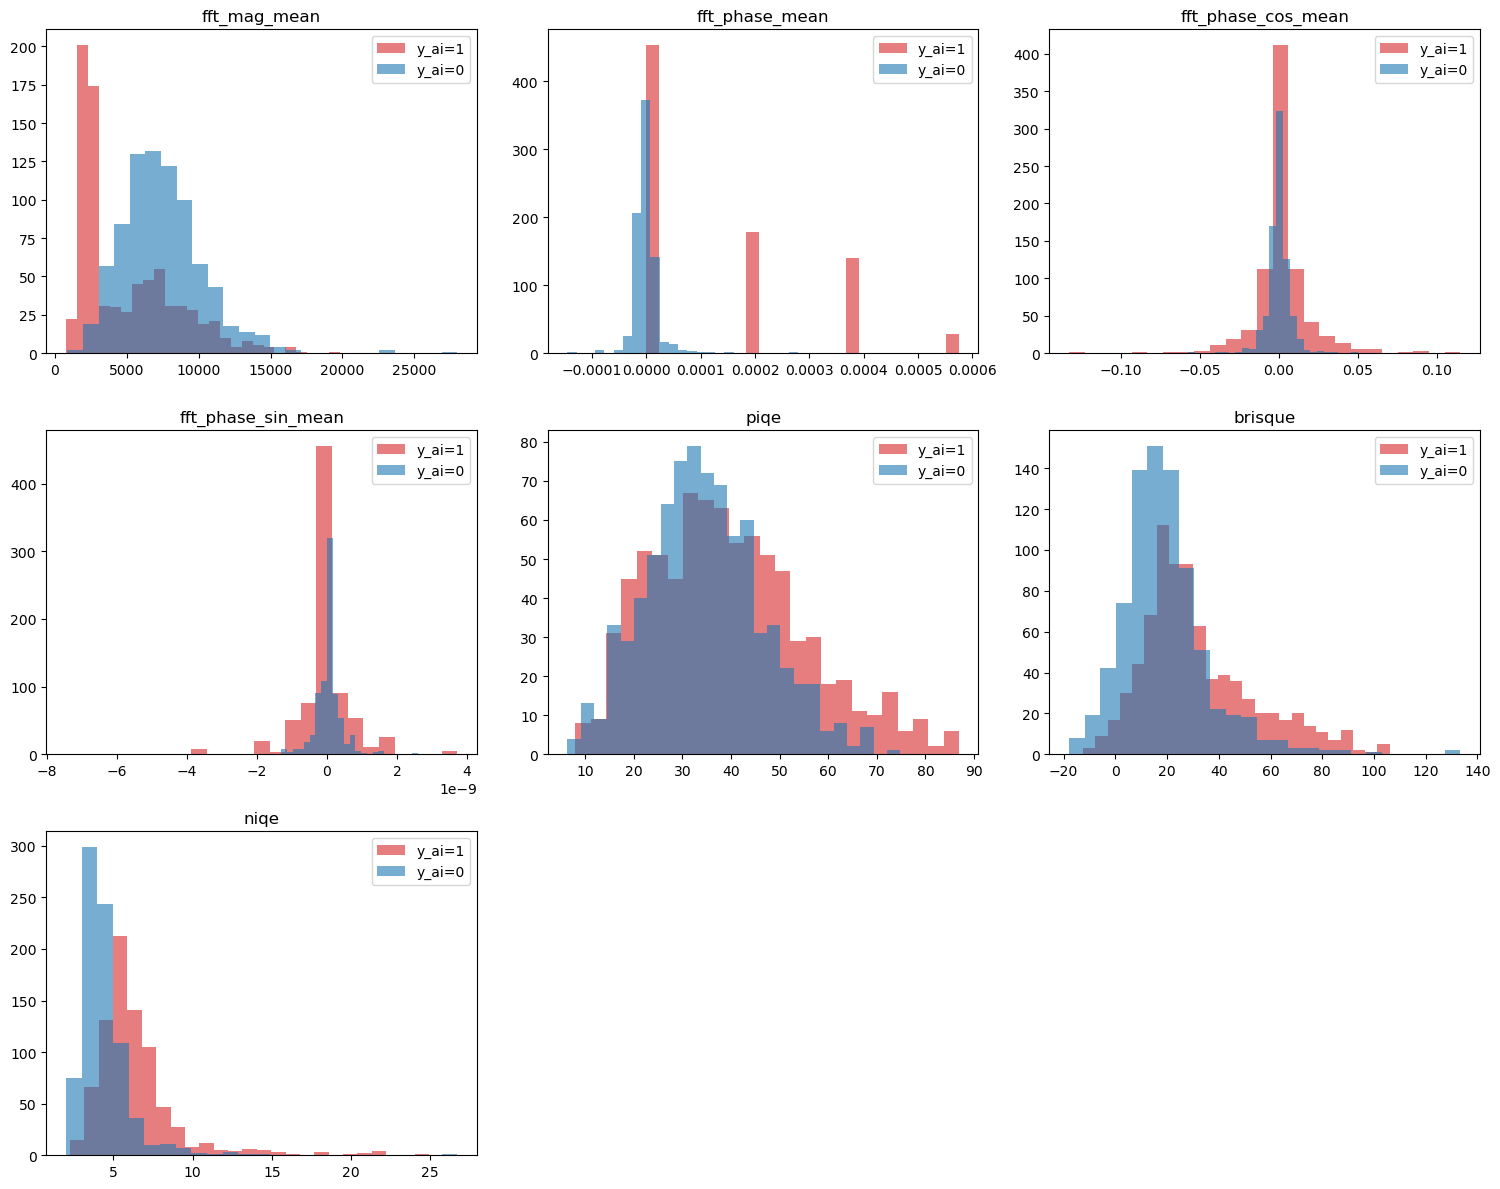

In [6]:
plot_cols = ["fft_mag_mean", "fft_phase_mean", "fft_phase_cos_mean", "fft_phase_sin_mean", "piqe", "brisque", "niqe"]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for ax, col in zip(axes, plot_cols):
    for label, color in [(1, "tab:red"), (0, "tab:blue")]:
        ax.hist(data[data["y_ai"] == label][col], bins=25, alpha=0.6, label=f"y_ai={label}", color=color)
    ax.set_title(col)
    ax.legend()
for ax in axes[len(plot_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Split 80:20 dengan stratifikasi gabungan

In [7]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)
stratify_key = data["generator"].astype(str) + "|" + data["y_ai"].astype(str) + "|" + data["content_label"].astype(str)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=stratify_key
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (1280, 71) (1280,)
Eval: (320, 71) (320,)


## 6. Train baseline

In [8]:
MLP_HIDDEN = (128, 64)
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=MLP_HIDDEN, activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,XGBoost,0.98125,0.981250,0.998594
1,MLP,0.95625,0.956522,0.994688


## 7. Confusion matrix model terbaik

Best model: XGBoost

              precision    recall  f1-score   support

      nature       0.98      0.98      0.98       160
          ai       0.98      0.98      0.98       160

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320



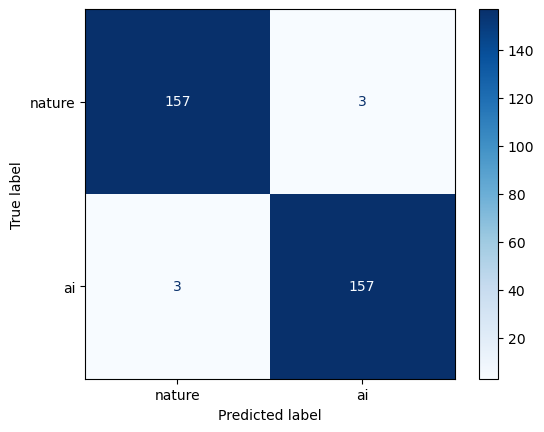

In [9]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 8. Simpan hasil

In [10]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "iqa_plus_fft_plus_clip"
metrics_df["iqa_metrics"] = "piqe,brisque,niqe"
metrics_df["clip_model"] = CLIP_MODEL_NAME
metrics_df["clip_out_dim"] = CLIP_OUT_DIM
metrics_df["split_protocol"] = "train_holdout_80_20_stratified_generator_label_class"
metrics_df["subset_name"] = SUBSET_NAME
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "generator", "class_name", "content_id", "content_label", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())

Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_biggan_midjourney_common4_iqa_fft_clip.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_biggan_midjourney_common4_iqa_fft_clip.csv


,model,accuracy,f1,auroc,feature_set,iqa_metrics,clip_model,clip_out_dim,split_protocol,subset_name,n_total,n_train,n_eval
0,XGBoost,0.98125,0.981250,0.998594,iqa_plus_fft_plus_clip,"piqe,brisque,niqe",openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_common4_train,1600,1280,320
1,MLP,0.95625,0.956522,0.994688,iqa_plus_fft_plus_clip,"piqe,brisque,niqe",openai/clip-vit-base-patch32,64,train_holdout_80_20_stratified_generator_label...,biggan_midjourney_common4_train,1600,1280,320


,image_id,path,generator,class_name,content_id,content_label,y_ai,model,score_ai,pred_ai
0,img_a36d38447a083737,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,MidJourney,ai,114,slug,1,XGBoost,0.998985,1
1,img_c21168e02144ae54,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n03769881,minibus,0,XGBoost,0.004095,0
2,img_eaafbe4bf30ace8b,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n01945685,slug,0,XGBoost,0.001316,0
3,img_7b7da66f2ea0c42c,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,nature,n02123045,tabby,0,XGBoost,0.000524,0
4,img_4a16ccda301be26d,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,BigGAN,ai,114,slug,1,XGBoost,0.997388,1


## 9. Catatan interpretasi

Notebook ini adalah gabungan penuh dari tiga keluarga fitur: NR-IQA, spektral FFT, dan semantik CLIP. Ini bisa dipakai sebagai eksperimen gabungan terlengkap pada setup dua generator dan empat class yang sama.